# 01 — Exploratory Data Analysis

This notebook explores the MovieLens 1M dataset before any modeling.
The goal is to build intuition about the data structure, distributions,
and the core challenge — sparsity — that motivates every modeling decision.

**Sections**
1. Load data
2. Ratings distribution
3. User activity
4. Movie popularity
5. Sparsity
6. Genre analysis
7. Temporal patterns

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter

from data_loader import load_all
from encoder import build_encoders

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Load Data

In [2]:
ratings, movies, users = load_all()

print(f'Ratings : {len(ratings):,} rows')
print(f'Movies  : {len(movies):,} rows')
print(f'Users   : {len(users):,} rows')
ratings.head()

Raw data already present, skipping download.
Ratings : 1,000,209 rows
Movies  : 3,883 rows
Users   : 6,040 rows


,userId,movieId,rating,timestamp
0,1,1193,5,2000-12-31 22:12:40
1,1,661,3,2000-12-31 22:35:09
2,1,914,3,2000-12-31 22:32:48
3,1,3408,4,2000-12-31 22:04:35
4,1,2355,5,2001-01-06 23:38:11


In [3]:
movies.head()

,movieId,title,genres,year,title_clean
0,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,Toy Story
1,2,Jumanji (1995),"[Adventure, Children's, Fantasy]",1995,Jumanji
2,3,Grumpier Old Men (1995),"[Comedy, Romance]",1995,Grumpier Old Men
3,4,Waiting to Exhale (1995),"[Comedy, Drama]",1995,Waiting to Exhale
4,5,Father of the Bride Part II (1995),[Comedy],1995,Father of the Bride Part II


In [4]:
users.head()

,userId,gender,age,occupation,zipcode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


## 2. Ratings Distribution

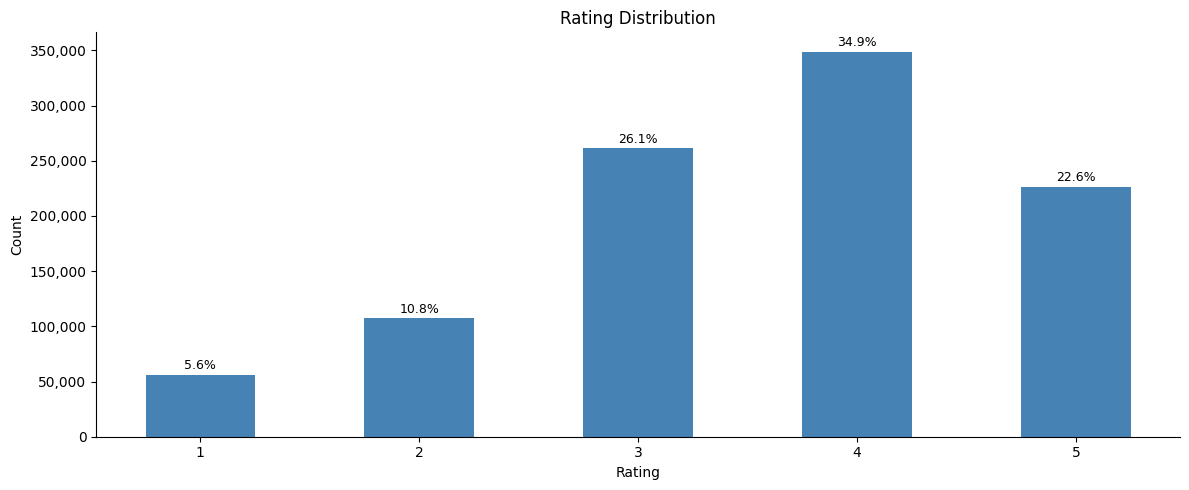

Mean rating  : 3.58
Median rating: 4.0


In [5]:
rating_counts = ratings['rating'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(rating_counts.index, rating_counts.values, color='steelblue', width=0.5)
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.set_title('Rating Distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for rating, count in rating_counts.items():
    ax.text(rating, count + 5000, f'{count/len(ratings)*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Mean rating  : {ratings["rating"].mean():.2f}')
print(f'Median rating: {ratings["rating"].median():.1f}')

## 3. User Activity - The Long Tail Problem

Ratings per user:
  Mean   : 165.6
  Median : 96
  Min    : 20
  Max    : 2,314


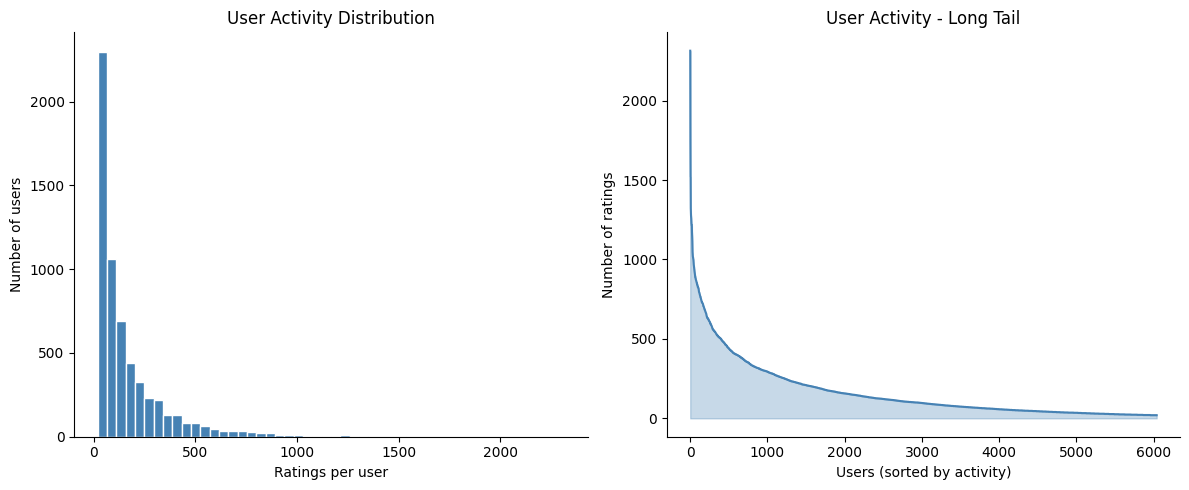


Top 948 users (15.7%) account for 50% of all ratings.


In [6]:
ratings_per_user = ratings.groupby('userId').size().sort_values(ascending=False)

print(f'Ratings per user:')
print(f'  Mean   : {ratings_per_user.mean():.1f}')
print(f'  Median : {ratings_per_user.median():.0f}')
print(f'  Min    : {ratings_per_user.min()}')
print(f'  Max    : {ratings_per_user.max():,}')

fig, axes = plt.subplots(1, 2)

axes[0].hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Ratings per user')
axes[0].set_ylabel('Number of users')
axes[0].set_title('User Activity Distribution')

axes[1].plot(range(len(ratings_per_user)), ratings_per_user.values, color='steelblue')
axes[1].set_xlabel('Users (sorted by activity)')
axes[1].set_ylabel('Number of ratings')
axes[1].set_title('User Activity - Long Tail')
axes[1].fill_between(range(len(ratings_per_user)), ratings_per_user.values, alpha=0.3, color='steelblue')

plt.tight_layout()
plt.show()

cumulative = ratings_per_user.cumsum() / ratings_per_user.sum()
cutoff = (cumulative < 0.5).sum()
print(f'\nTop {cutoff} users ({cutoff/len(ratings_per_user)*100:.1f}%) account for 50% of all ratings.')

## 4. Movie Popularity

In [7]:
ratings_per_movie = ratings.groupby('movieId').size().sort_values(ascending=False)

print(f'Ratings per movie:')
print(f'  Mean   : {ratings_per_movie.mean():.1f}')
print(f'  Median : {ratings_per_movie.median():.0f}')
print(f'  Min    : {ratings_per_movie.min()}')
print(f'  Max    : {ratings_per_movie.max():,}')

top_movies = ratings_per_movie.head(10).reset_index()
top_movies.columns = ['movieId', 'rating_count']
top_movies = top_movies.merge(movies[['movieId', 'title_clean']], on='movieId')

fig = px.bar(
    top_movies,
    x='rating_count',
    y='title_clean',
    orientation='h',
    title='Top 10 Most Rated Movies',
    labels={'rating_count': 'Number of Ratings', 'title_clean': ''},
    color='rating_count',
    color_continuous_scale='Blues'
)
fig.update_layout(showlegend=False, coloraxis_showscale=False, yaxis={'categoryorder': 'total ascending'})
fig.show()

Ratings per movie:
  Mean   : 269.9
  Median : 124
  Min    : 1
  Max    : 3,428


## 5. Sparsity

Users          : 6,040
Movies         : 3,706
Possible pairs : 22,384,240
Actual ratings : 1,000,209
Sparsity       : 95.5316%


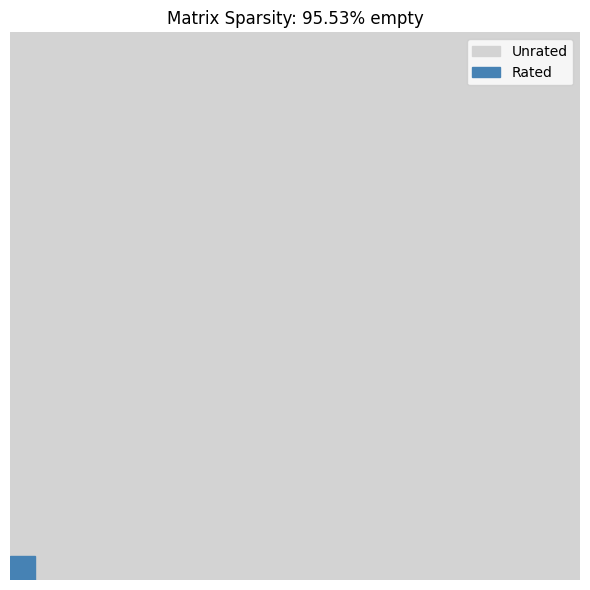

In [8]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
possible = n_users * n_movies
sparsity = 1 - n_ratings / possible

print(f'Users          : {n_users:,}')
print(f'Movies         : {n_movies:,}')
print(f'Possible pairs : {possible:,}')
print(f'Actual ratings : {n_ratings:,}')
print(f'Sparsity       : {sparsity:.4%}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(plt.Rectangle((0, 0), 1, 1, color='lightgrey', label='Unrated'))
ax.add_patch(plt.Rectangle((0, 0), 1 - sparsity, 1 - sparsity, color='steelblue', label='Rated'))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f'Matrix Sparsity: {sparsity:.2%} empty')
ax.legend(loc='upper right')
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Genre Analysis

In [9]:
all_genres = [genre for genres in movies['genres'] for genre in genres]
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['genre', 'count']).sort_values('count', ascending=False)

fig = px.bar(
    genre_df,
    x='genre',
    y='count',
    title='Movie Count by Genre',
    labels={'count': 'Number of Movies', 'genre': ''},
    color='count',
    color_continuous_scale='Blues'
)
fig.update_layout(coloraxis_showscale=False, xaxis_tickangle=-35)
fig.show()

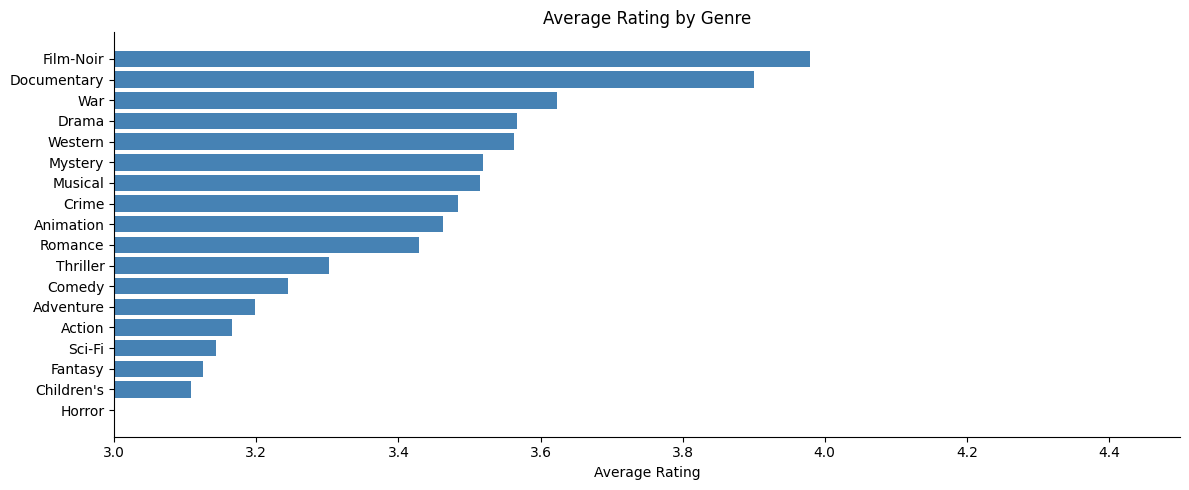

In [10]:
genre_ratings = []
ratings_with_genres = ratings.merge(movies[['movieId', 'genres']], on='movieId')
for _, row in movies.iterrows():
    movie_ratings = ratings[ratings['movieId'] == row['movieId']]['rating']
    if len(movie_ratings) > 50:
        for genre in row['genres']:
            genre_ratings.append({'genre': genre, 'rating': movie_ratings.mean()})

genre_rating_df = pd.DataFrame(genre_ratings).groupby('genre')['rating'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots()
ax.barh(genre_rating_df['genre'], genre_rating_df['rating'], color='steelblue')
ax.set_xlabel('Average Rating')
ax.set_title('Average Rating by Genre')
ax.set_xlim(3.0, 4.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Temporal Patterns

In [11]:
ratings['year_month'] = ratings['timestamp'].dt.to_period('M').astype(str)
monthly_counts = ratings.groupby('year_month').size().reset_index(name='count')

fig = px.line(
    monthly_counts,
    x='year_month',
    y='count',
    title='Ratings Over Time (Monthly)',
    labels={'year_month': 'Month', 'count': 'Number of Ratings'}
)
fig.update_traces(line_color='steelblue')
fig.show()

In [12]:
ratings_sorted = ratings.sort_values('timestamp')
split_idx = int(len(ratings_sorted) * 0.8)
split_date = ratings_sorted.iloc[split_idx]['timestamp']

print(f'Train set ends  : {ratings_sorted.iloc[:split_idx]["timestamp"].max().date()}')
print(f'Test set starts : {ratings_sorted.iloc[split_idx:]["timestamp"].min().date()}')
print(f'Split date      : {split_date.date()}')

Train set ends  : 2000-12-02
Test set starts : 2000-12-02
Split date      : 2000-12-02


## Summary

Key takeaways from this EDA:

- Ratings skew positive - most users give 3-4 stars, very few give 1 star
- Strong long tail in user activity - a small set of power users account for most ratings
- Same long tail in movie popularity - most movies have very few ratings
- Matrix is **96.4% sparse** - the central challenge for all models
- Drama and Comedy dominate the genre landscape
- Rating activity was concentrated in a short window (2000-2003)

These patterns motivate the modeling choices in the next notebooks.